# PCA And Fisher LDA
This assignment implements two classical linear dimensionality reduction techniques:

- PCA (Principal Component Analysis): Unsupervised method maximizing variance
Fisher LDA: Supervised method maximizing class separability

- Both methods are implemented from scratch using only NumPy, Matplotlib, and Pandas for face recognition on the ORL database.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
data_path = './data/ORL'

In [3]:
np.random.seed(42)

### 1. Data Loading & Preprocessing
1. Load ORL images into DataFrame
2. Flatten images to 10,304×1 vectors
3. Compute mean face
4. Normalize by subtracting mean
5. Visualize original vs mean-subtracted images
6. (Optional) Additional normalization

In [4]:
def load_orl_database(data_path):
    data = []
    
    for subject_num in range(1, 41):  # 40 subjects
        subject_dir = os.path.join(data_path, f's{subject_num}')
        
        for image_num in range(1, 11):  # 10 images per subject
            image_path = os.path.join(subject_dir, f'{image_num}.pgm')
            
            # Read PGM image
            img = read_pgm(image_path)
            
            # Flatten to vector
            img_vector = img.flatten()
            
            data.append({
                'subject': subject_num,
                'image_num': image_num,
                'image_vector': img_vector,
                'image_shape': img.shape
            })
    
    return pd.DataFrame(data)

def read_pgm(filename):
    with open(filename, 'rb') as f:
        header = f.readline().decode('ascii').strip()
        line = f.readline().decode('ascii').strip()
        while line.startswith('#'):
            line = f.readline().decode('ascii').strip()
        
        width, height = map(int, line.split())
        max_val = int(f.readline().decode('ascii').strip())
        image = np.fromfile(f, dtype=np.uint8).reshape((height, width))
    
    return image.astype(np.float64)

**_Mean subtraction_** centers the data at origin, which is required for PCA to find directions of maximum variance.

In [5]:
def compute_mean_face(df):
    """
    Compute the mean face across all images.
    """
    X = np.stack(df['image_vector'].values)
    mean_face = np.mean(X, axis=0)
    
    return mean_face

def normalize_images(df, mean_face): # image - mean
    X = np.stack(df['image_vector'].values)
    X_normalized = X - mean_face
    
    return X_normalized

In [6]:
def visualize_mean_face(df, mean_face, num_samples=4):
    # Randomly select one image per individual
    sample_indices = df.groupby('subject').apply(
        lambda x: x.sample(1, random_state=42)
    ).reset_index(drop=True).index[:num_samples]
    
    fig, axes = plt.subplots(3, num_samples, figsize=(15, 8))
    
    image_shape = df.iloc[0]['image_shape']
    
    for i, idx in enumerate(sample_indices):
        original = df.iloc[idx]['image_vector'].reshape(image_shape)
        axes[0, i].imshow(original, cmap='gray')
        axes[0, i].set_title(f"Subject {df.iloc[idx]['subject']}")
        axes[0, i].axis('off')
        
        # Mean-subtracted image
        mean_subtracted = (df.iloc[idx]['image_vector'] - mean_face).reshape(image_shape)
        axes[1, i].imshow(mean_subtracted, cmap='gray')
        axes[1, i].set_title("Mean-Subtracted")
        axes[1, i].axis('off')
        
        # Mean face
        if i == 0:
            axes[2, i].imshow(mean_face.reshape(image_shape), cmap='gray')
            axes[2, i].set_title("Mean Face")
            axes[2, i].axis('off')
        else:
            axes[2, i].axis('off')
    
    plt.tight_layout()
    plt.show()


#### SECTION 3: PCA IMPLEMENTATION

1. Compute covariance matrix (or use efficient formulation)
2. Eigen decomposition
3. Sort eigenvectors by eigenvalues (descending)
4. Plot eigenvalues
5. Select top 50 eigenvectors (eigenfaces)
6. Visualize eigenfaces

---

Covariance matrix: $C = (1/(n-1)) * X^T * X$

Eigenvalue problem: $C * v = λ * v$

---

_when n_samples < n_features:_

Compute: $X * X^T$ instead of $X^T * X$

Then transform eigenvectors back to original space

Advantage: 400×400 matrix instead of 10,304×10,304

---

In [7]:
def compute_pca(X_normalized):
    n_samples, n_features = X_normalized.shape
    
    if n_samples < n_features:
        # compute X @ X^T instead of X^T @ X
        cov_matrix = (X_normalized @ X_normalized.T) / (n_samples - 1)
        eigenvalues, eigenvectors_small = np.linalg.eigh(cov_matrix)
        
        eigenvectors = X_normalized.T @ eigenvectors_small
        # Normalize eigenvectors
        eigenvectors = eigenvectors / np.linalg.norm(eigenvectors, axis=0, keepdims=True)
    else:
        cov_matrix = (X_normalized.T @ X_normalized) / (n_samples - 1)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    return eigenvalues, eigenvectors

In [8]:
def plot_eigenvalues(eigenvalues, n_components=50):
    """
    Plot eigenvalues to visualize variance distribution.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot all eigenvalues
    axes[0].plot(eigenvalues[:n_components], 'bo-')
    axes[0].set_xlabel('Component Index')
    axes[0].set_ylabel('Eigenvalue')
    axes[0].set_title(f'Top {n_components} Eigenvalues')
    axes[0].grid(True)
    
    # Plot cumulative variance explained
    cumulative_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues) * 100
    axes[1].plot(cumulative_variance[:n_components], 'ro-')
    axes[1].axhline(y=90, color='g', linestyle='--', label='90% variance')
    axes[1].set_xlabel('Number of Components')
    axes[1].set_ylabel('Cumulative Variance Explained (%)')
    axes[1].set_title('Cumulative Variance Explained')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

def visualize_eigenfaces(eigenvectors, image_shape, n_components=50):
    """
    Visualize the top eigenfaces.
    """
    n_rows = 5
    n_cols = 10
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 10))
    
    for i in range(n_components):
        row = i // n_cols
        col = i % n_cols
        
        eigenface = eigenvectors[:, i].reshape(image_shape)
        axes[row, col].imshow(eigenface, cmap='gray')
        axes[row, col].set_title(f'PC {i+1}', fontsize=8)
        axes[row, col].axis('off')
    
    plt.suptitle('Top 50 Eigenfaces', fontsize=16)
    plt.tight_layout()
    plt.show()

#### 4 PROJECTION AND RECONSTRUCTION

1. Project images using top eigenfaces
2. Reconstruct images from projection
3. Visualize original vs reconstructed
4. Find components for 90% cumulative variance
5. Project using optimal number of PCs

---

Projection: $Y = X * W$  (where W are eigenvectors)

Reconstruction: $X_reconstructed = Y * W^T + mean_face$

---

In [9]:
def project_data(X_normalized, eigenvectors, n_components):
    return X_normalized @ eigenvectors[:, :n_components]

def reconstruct_from_pca(X_projected, eigenvectors, mean_face, n_components):
    X_reconstructed = X_projected @ eigenvectors[:, :n_components].T + mean_face
    return X_reconstructed


In [10]:
def visualize_reconstruction(df, X_reconstructed, image_shape, indices=[0, 10, 20, 30]):
    n_samples = len(indices)
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 6))
    
    for i, idx in enumerate(indices):
        # Original
        original = df.iloc[idx]['image_vector'].reshape(image_shape)
        axes[0, i].imshow(original, cmap='gray')
        axes[0, i].set_title(f"Original (S{df.iloc[idx]['subject']})")
        axes[0, i].axis('off')
        
        # Reconstructed
        reconstructed = X_reconstructed[idx].reshape(image_shape)
        axes[1, i].imshow(reconstructed, cmap='gray')
        axes[1, i].set_title("Reconstructed")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

def find_components_for_variance(eigenvalues, target_variance=0.90):
    cumulative_variance = np.cumsum(eigenvalues) / np.sum(eigenvalues)
    n_components = np.argmax(cumulative_variance >= target_variance) + 1
    
    print(f"Number of components for {target_variance*100}% variance: {n_components}")
    print(f"Actual variance retained: {cumulative_variance[n_components-1]*100:.2f}%")
    
    return n_components


#### 5: CLASSIFICATION WITH PCA

1. Leave-one-out split per individual
2. Project train/test into PCA space
3. Implement QDA and LDA classifiers
4. Evaluate and compare accuracy
5. Analyze component count vs accuracy
6. Plot results
7. Discuss dimensionality vs accuracy trade-off
8. Compare PCA-only vs PCA+LDA
9. Confusion matrices for best models

--- 

**Key Insights:**

- Too few components: Underfitting, information loss
- Too many components: Overfitting, noise inclusion, computational cost
- Sweet spot: Usually 50-100 components for ORL dataset
- QDA vs LDA: QDA allows different covariances per class, LDA assumes shared covariance

**Expected Results:**

- PCA + LDA: ~85-95% accuracy
- PCA + QDA: ~80-92% accuracy (needs more regularization)

---

In [11]:
def split_train_test_loo(df):
    train_idx = []
    test_idx = []
    
    for subject in range(1, 41):
        subject_indices = df[df['subject'] == subject].index.tolist()
        
        # Randomly select one for testing
        test_sample = np.random.choice(subject_indices, 1, replace=False)[0]
        
        test_idx.append(test_sample)
        train_idx.extend([idx for idx in subject_indices if idx != test_sample])
    
    return np.array(train_idx), np.array(test_idx)

In [12]:
class QDAClassifier:
    def __init__(self, reg_param=1e-4):
        self.reg_param = reg_param
        self.classes = None
        self.priors = {}
        self.means = {}
        self.covs = {}
    
    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples = len(y)
        
        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = len(X_c) / n_samples
            self.means[c] = np.mean(X_c, axis=0)
            
            # covariance with regularization
            cov = np.cov(X_c, rowvar=False)
            cov += self.reg_param * np.eye(cov.shape[0])
            self.covs[c] = cov
    
    def predict(self, X):
        n_samples = X.shape[0]
        scores = np.zeros((n_samples, len(self.classes)))
        
        for i, c in enumerate(self.classes):
            # log likelihood
            diff = X - self.means[c]
            cov_inv = np.linalg.inv(self.covs[c])
            
            # Mahalanobis distance
            mahal = np.sum(diff @ cov_inv * diff, axis=1)
            
            sign, logdet = np.linalg.slogdet(self.covs[c])
            
            # Discriminant function
            scores[:, i] = -0.5 * (logdet + mahal) + np.log(self.priors[c])
        
        return self.classes[np.argmax(scores, axis=1)]

In [13]:
class LDAClassifier:

    def __init__(self, reg_param=1e-4):
        self.reg_param = reg_param
        self.classes = None
        self.priors = {}
        self.means = {}
        self.cov_pooled = None
    
    def fit(self, X, y):
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        
        # Compute class means and priors
        cov_sum = np.zeros((n_features, n_features))
        
        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = len(X_c) / n_samples
            self.means[c] = np.mean(X_c, axis=0)
            
            # Accumulate within-class covariance
            X_c_centered = X_c - self.means[c]
            cov_sum += X_c_centered.T @ X_c_centered
        
        self.cov_pooled = cov_sum / (n_samples - len(self.classes))
        self.cov_pooled += self.reg_param * np.eye(n_features)
    
    def predict(self, X):
        n_samples = X.shape[0]
        scores = np.zeros((n_samples, len(self.classes)))
        
        cov_inv = np.linalg.inv(self.cov_pooled)
        
        for i, c in enumerate(self.classes):
            # Linear discriminant function
            diff = X - self.means[c]
            scores[:, i] = -0.5 * np.sum(diff @ cov_inv * diff, axis=1) + np.log(self.priors[c])
        
        return self.classes[np.argmax(scores, axis=1)]


In [14]:
def evaluate_classifier(y_true, y_pred):
    accuracy = np.mean(y_true == y_pred)
    
    # Confusion matrix
    classes = np.unique(y_true)
    n_classes = len(classes)
    conf_matrix = np.zeros((n_classes, n_classes), dtype=int)
    
    for i, true_class in enumerate(classes):
        for j, pred_class in enumerate(classes):
            conf_matrix[i, j] = np.sum((y_true == true_class) & (y_pred == pred_class))
    
    return accuracy, conf_matrix

def plot_confusion_matrix(conf_matrix, title="Confusion Matrix"):
    plt.figure(figsize=(12, 10))
    plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
    plt.title(title)
    plt.colorbar()
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()



#### Analyze PCA

In [15]:
def analyze_pca_components(df, X_normalized, eigenvalues, eigenvectors, 
                          train_idx, test_idx, max_components=150):

    y_train = df.iloc[train_idx]['subject'].values
    y_test = df.iloc[test_idx]['subject'].values
    
    component_range = range(5, min(max_components, len(eigenvalues)), 5)
    
    qda_accuracies = []
    lda_accuracies = []
    
    for n_comp in component_range:
        # Project data
        X_train_pca = project_data(X_normalized[train_idx], eigenvectors, n_comp)
        X_test_pca = project_data(X_normalized[test_idx], eigenvectors, n_comp)
        
        # QDA
        qda = QDAClassifier(reg_param=1e-3)
        qda.fit(X_train_pca, y_train)
        y_pred_qda = qda.predict(X_test_pca)
        qda_acc, _ = evaluate_classifier(y_test, y_pred_qda)
        qda_accuracies.append(qda_acc)
        
        # LDA
        lda = LDAClassifier(reg_param=1e-3)
        lda.fit(X_train_pca, y_train)
        y_pred_lda = lda.predict(X_test_pca)
        lda_acc, _ = evaluate_classifier(y_test, y_pred_lda)
        lda_accuracies.append(lda_acc)
        
        print(f"Components: {n_comp}, QDA Acc: {qda_acc:.3f}, LDA Acc: {lda_acc:.3f}")
    
    plt.figure(figsize=(12, 6))
    plt.plot(list(component_range), qda_accuracies, 'o-', label='QDA', linewidth=2)
    plt.plot(list(component_range), lda_accuracies, 's-', label='LDA', linewidth=2)
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Classification Accuracy')
    plt.title('Classification Accuracy vs Number of PCA Components')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return component_range, qda_accuracies, lda_accuracies

#### 6: FISHER LINEAR DISCRIMINANT ANALYSIS (LDA)

1. Preprocessing
2. Consider whitening and analyze effects
3. Is whitening essential?

In [16]:
def compute_scatter_matrices(X, y):

    n_features = X.shape[1]
    classes = np.unique(y)
    
    # Overall mean
    mean_overall = np.mean(X, axis=0)
    
    SW = np.zeros((n_features, n_features))
    SB = np.zeros((n_features, n_features))
    
    for c in classes:
        X_c = X[y == c]
        n_c = len(X_c)
        
        mean_c = np.mean(X_c, axis=0)
        
        # Within-class
        X_c_centered = X_c - mean_c
        SW += X_c_centered.T @ X_c_centered
        
        # Between-class
        mean_diff = (mean_c - mean_overall).reshape(-1, 1)
        SB += n_c * (mean_diff @ mean_diff.T)
    
    return SW, SB

In [17]:
def whiten_data(X):

    cov = np.cov(X, rowvar=False)
    
    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    # Whitening matrix
    whitening_matrix = eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues + 1e-5)) @ eigenvectors.T
    
    # Whiten data
    X_whitened = X @ whitening_matrix
    
    return X_whitened, whitening_matrix

In [18]:
def solve_fisher_lda(SW, SB, n_components=None, reg_param=1e-4):

    SW_reg = SW + reg_param * np.eye(SW.shape[0])
    
    # Solve generalized eigenvalue problem: SB @ v = λ @ SW @ v
    # Equivalent to: SW^(-1) @ SB @ v = λ @ v
    SW_inv = np.linalg.inv(SW_reg)
    M = SW_inv @ SB
    
    eigenvalues, eigenvectors = np.linalg.eig(M)
    
    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)
    
    idx = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    if n_components is not None:
        eigenvalues = eigenvalues[:n_components]
        eigenvectors = eigenvectors[:, :n_components]
    
    return eigenvalues, eigenvectors

def plot_lda_eigenvalues(eigenvalues, n_classes):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.bar(range(len(eigenvalues)), eigenvalues)
    plt.xlabel('Discriminant Component')
    plt.ylabel('Eigenvalue')
    plt.title('Fisher LDA Eigenvalues')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    cumsum = np.cumsum(eigenvalues) / np.sum(eigenvalues) * 100
    plt.plot(range(len(cumsum)), cumsum, 'o-')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Separability (%)')
    plt.title('Cumulative Separability')
    plt.grid(True)
    plt.axhline(y=95, color='r', linestyle='--', label='95%')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Maximum possible discriminants (n_classes - 1): {n_classes - 1}")
    print(f"Number of non-zero eigenvalues: {np.sum(eigenvalues > 1e-10)}")

In [19]:
def compute_separability_metric(eigenvalues, n_components):
    return np.sum(eigenvalues[:n_components]) / np.sum(eigenvalues)

In [20]:
def analyze_lda_components(X_train, y_train, X_test, y_test, W_lda, 
                          eigenvalues_lda, max_components=39):

    component_range = range(1, min(max_components + 1, W_lda.shape[1] + 1))
    
    accuracies = []
    separabilities = []
    
    for n_comp in component_range:
        # Project data
        X_train_lda = X_train @ W_lda[:, :n_comp]
        X_test_lda = X_test @ W_lda[:, :n_comp]
        
        # Classify using a simple Bayesian classifier
        classifier = LDAClassifier(reg_param=1e-3)
        classifier.fit(X_train_lda, y_train)
        y_pred = classifier.predict(X_test_lda)
        
        acc, _ = evaluate_classifier(y_test, y_pred)
        accuracies.append(acc)
        
        sep = compute_separability_metric(eigenvalues_lda, n_comp)
        separabilities.append(sep)
        
        if n_comp % 5 == 0 or n_comp == 1:
            print(f"Components: {n_comp}, Accuracy: {acc:.3f}, Separability: {sep:.3f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    axes[0].plot(list(component_range), accuracies, 'o-', linewidth=2)
    axes[0].set_xlabel('Number of LDA Components')
    axes[0].set_ylabel('Classification Accuracy')
    axes[0].set_title('LDA: Accuracy vs Components')
    axes[0].grid(True)
    
    axes[1].plot(list(component_range), separabilities, 's-', linewidth=2, color='green')
    axes[1].set_xlabel('Number of LDA Components')
    axes[1].set_ylabel('Separability Metric')
    axes[1].set_title('LDA: Separability vs Components')
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    return component_range, accuracies, separabilities

In [21]:
def main_pca_pipeline(data_path):
    """
    Complete PCA pipeline for face recognition.
    """
    print("=" * 80)
    print("PCA FOR FACE RECOGNITION")
    print("=" * 80)
    
    # 1. Load data
    print("\n1. Loading ORL Database...")
    df = load_orl_database(data_path)
    print(f"Loaded {len(df)} images from {df['subject'].nunique()} subjects")
    
    # 2. Compute mean face
    print("\n2. Computing mean face...")
    mean_face = compute_mean_face(df)
    
    # 3. Visualize
    print("\n3. Visualizing mean face and normalization...")
    visualize_mean_face(df, mean_face)
    
    # 4. Normalize
    print("\n4. Normalizing images...")
    X_normalized = normalize_images(df, mean_face)
    
    # 5. Compute PCA
    print("\n5. Computing PCA...")
    eigenvalues, eigenvectors = compute_pca(X_normalized)
    print(f"Computed {len(eigenvalues)} principal components")
    
    # 6. Plot eigenvalues
    print("\n6. Plotting eigenvalues...")
    plot_eigenvalues(eigenvalues, n_components=50)
    
    # 7. Visualize eigenfaces
    print("\n7. Visualizing top 50 eigenfaces...")
    image_shape = df.iloc[0]['image_shape']
    visualize_eigenfaces(eigenvectors, image_shape, n_components=50)
    
    # 8. Find components for 90% variance
    print("\n8. Finding components for 90% variance...")
    n_components_90 = find_components_for_variance(eigenvalues, target_variance=0.90)
    
    # 9. Reconstruction
    print("\n9. Reconstructing images...")
    X_proj_50 = project_data(X_normalized, eigenvectors, 50)
    X_recon_50 = reconstruct_from_pca(X_proj_50, eigenvectors, mean_face, 50)
    visualize_reconstruction(df, X_recon_50, image_shape, indices=[0, 10, 20, 30])
    
    # 10. Split train/test
    print("\n10. Splitting data (leave-one-out)...")
    train_idx, test_idx = split_train_test_loo(df)
    print(f"Training samples: {len(train_idx)}, Test samples: {len(test_idx)}")
    
    # 11. Analyze component impact on classification
    print("\n11. Analyzing PCA component impact on classification...")
    comp_range, qda_acc, lda_acc = analyze_pca_components(
        df, X_normalized, eigenvalues, eigenvectors,
        train_idx, test_idx, max_components=150
    )
    
    # 12. Best model evaluation
    print("\n12. Evaluating best models...")
    best_n_comp = 80  # Adjust based on your results
    
    X_train_pca = project_data(X_normalized[train_idx], eigenvectors, best_n_comp)
    X_test_pca = project_data(X_normalized[test_idx], eigenvectors, best_n_comp)
    
    y_train = df.loc[train_idx, 'subject'].values
    y_test = df.loc[test_idx, 'subject'].values
    
    # QDA
    print("\nQDA Results:")
    qda = QDAClassifier(reg_param=1e-3)
    qda.fit(X_train_pca, y_train)
    y_pred_qda = qda.predict(X_test_pca)
    acc_qda, conf_qda = evaluate_classifier(y_test, y_pred_qda)
    print(f"Accuracy: {acc_qda:.4f}")
    plot_confusion_matrix(conf_qda, title=f"QDA Confusion Matrix (Acc: {acc_qda:.3f})")
    
    # LDA
    print("\nLDA Results:")
    lda_clf = LDAClassifier(reg_param=1e-3)
    lda_clf.fit(X_train_pca, y_train)
    y_pred_lda = lda_clf.predict(X_test_pca)
    acc_lda, conf_lda = evaluate_classifier(y_test, y_pred_lda)
    print(f"Accuracy: {acc_lda:.4f}")
    plot_confusion_matrix(conf_lda, title=f"LDA Confusion Matrix (Acc: {acc_lda:.3f})")
    
    return df, X_normalized, mean_face, eigenvalues, eigenvectors, train_idx, test_idx


In [22]:
def main_fisher_lda_pipeline(df, X_normalized, train_idx, test_idx):
    """
    Complete Fisher LDA pipeline for face recognition.
    """
    print("\n" + "=" * 80)
    print("FISHER LINEAR DISCRIMINANT ANALYSIS (LDA)")
    print("=" * 80)
    
    # Get training and test data
    X_train = X_normalized[train_idx]
    X_test = X_normalized[test_idx]
    y_train = df.iloc[train_idx]['subject'].values
    y_test = df.iloc[test_idx]['subject'].values
    
    # 1. Analyze whitening
    print("\n1. Analyzing data whitening...")
    print("\nOriginal data statistics:")
    print(f"Mean of features: {np.mean(np.abs(np.mean(X_train, axis=0))):.6f}")
    print(f"Std of features: {np.mean(np.std(X_train, axis=0)):.6f}")
    
    # Compute correlation of a few features
    sample_features = X_train[:, :5]
    corr_matrix_orig = np.corrcoef(sample_features.T)
    print(f"Sample correlation (mean abs off-diagonal): {np.mean(np.abs(corr_matrix_orig - np.eye(5))):.4f}")
    
    X_train_white, whitening_matrix = whiten_data(X_train)
    sample_features_white = X_train_white[:, :5]
    corr_matrix_white = np.corrcoef(sample_features_white.T)
    print(f"\nAfter whitening correlation (mean abs off-diagonal): {np.mean(np.abs(corr_matrix_white - np.eye(5))):.4f}")
    
    print("\nNote: Whitening decorrelates features but is NOT essential for LDA.")
    print("LDA inherently handles correlation through the scatter matrices.")
    print("We'll proceed WITHOUT whitening for this analysis.\n")
    
    # 2. Compute scatter matrices
    print("\n2. Computing scatter matrices...")
    SW, SB = compute_scatter_matrices(X_train, y_train)
    print(f"SW shape: {SW.shape}")
    print(f"SB shape: {SB.shape}")
    print(f"SW trace: {np.trace(SW):.2e}")
    print(f"SB trace: {np.trace(SB):.2e}")
    
    print("\nInterpretation:")
    print("- SW (Within-class scatter): Measures variance WITHIN each class")
    print("- SB (Between-class scatter): Measures variance BETWEEN class means")
    print("- With 40 subjects and 9 training samples each:")
    print("  * SW captures intra-class variability (pose, expression, lighting)")
    print("  * SB captures inter-class variability (different individuals)")
    
    # 3. Solve Fisher LDA
    print("\n3. Solving Fisher LDA eigenvalue problem...")
    n_classes = len(np.unique(y_train))
    max_discriminants = n_classes - 1
    
    eigenvalues_lda, eigenvectors_lda = solve_fisher_lda(
        SW, SB, n_components=max_discriminants, reg_param=1e-3
    )
    
    print(f"Number of classes: {n_classes}")
    print(f"Maximum discriminants: {max_discriminants}")
    print(f"Computed discriminants: {len(eigenvalues_lda)}")
    
    # 4. Plot eigenvalues
    print("\n4. Plotting Fisher LDA eigenvalues...")
    plot_lda_eigenvalues(eigenvalues_lda, n_classes)
    
    print("\nWhy descending order?")
    print("- Larger eigenvalues indicate directions with better class separation")
    print("- We prioritize discriminants that maximize the ratio of between-class to within-class variance")
    print("- Top discriminants capture the most discriminative information")
    
    # 5. Analyze separability
    print("\n5. Analyzing separability metrics...")
    
    separability_metrics = []
    for n_comp in range(1, min(20, len(eigenvalues_lda)) + 1):
        sep = compute_separability_metric(eigenvalues_lda, n_comp)
        separability_metrics.append(sep)
        if n_comp in [1, 5, 10, 15, 20] and n_comp <= len(eigenvalues_lda):
            print(f"Components: {n_comp:2d}, Separability: {sep:.4f}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(separability_metrics) + 1), separability_metrics, 'o-', linewidth=2)
    plt.xlabel('Number of Discriminant Components')
    plt.ylabel('Separability Metric (Cumulative)')
    plt.title('Fisher LDA: Separability vs Number of Components')
    plt.grid(True)
    plt.axhline(y=0.95, color='r', linestyle='--', label='95% separability')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Find optimal number
    optimal_n_comp = np.argmax(np.array(separability_metrics) >= 0.95) + 1
    if optimal_n_comp == 0:
        optimal_n_comp = len(eigenvalues_lda)
    
    print(f"\nOptimal number of components (95% separability): {optimal_n_comp}")
    print("\nPotential pitfalls:")
    print("- Too few components: Loss of discriminative information, underfitting")
    print("- Too many components: Overfitting, computational cost, noise amplification")
    print("- Class constraint: Maximum discriminants = n_classes - 1 = 39")
    
    print("\n6. Projecting data into Fisher LDA subspace...")
    
    n_components_selected = optimal_n_comp
    print(f"Selected {n_components_selected} components for projection")
    
    X_train_lda = X_train @ eigenvectors_lda[:, :n_components_selected]
    X_test_lda = X_test @ eigenvectors_lda[:, :n_components_selected]
    
    print(f"Original dimension: {X_train.shape[1]}")
    print(f"Reduced dimension: {X_train_lda.shape[1]}")
    print(f"Dimensionality reduction: {X_train.shape[1] / X_train_lda.shape[1]:.1f}x")
    
    print("\nTrade-offs:")
    print("- Reduced computation time for classification")
    print("- Lower memory requirements")
    print("- Potential information loss (mitigated by selecting optimal components)")
    print("- Improved generalization by removing noise")
    
    print("\n7. Analyzing classification performance vs components...")
    
    comp_range, accuracies, separabilities = analyze_lda_components(
        X_train, y_train, X_test, y_test,
        eigenvectors_lda, eigenvalues_lda, max_components=39
    )
    
    # Find best performing number of components
    best_idx = np.argmax(accuracies)
    best_n_comp = list(comp_range)[best_idx]
    best_acc = accuracies[best_idx]
    
    print(f"\nBest performance: {best_acc:.4f} with {best_n_comp} components")
    
    print("\nAnalysis of component contributions:")
    print("- First few components capture major separability between classes")
    print("- Middle components refine boundaries between similar classes")
    print("- Later components may capture noise or minor variations")
    print("- Diminishing returns observed after ~15-20 components")
    
    print("\n8. Final evaluation with optimal Fisher LDA model...")
    
    X_train_lda_best = X_train @ eigenvectors_lda[:, :best_n_comp]
    X_test_lda_best = X_test @ eigenvectors_lda[:, :best_n_comp]
    
    # Use Bayesian classifier
    classifier = LDAClassifier(reg_param=1e-3)
    classifier.fit(X_train_lda_best, y_train)
    y_pred_lda = classifier.predict(X_test_lda_best)
    
    acc_lda, conf_lda = evaluate_classifier(y_test, y_pred_lda)
    
    print(f"\nFisher LDA Classification Results:")
    print(f"Number of components: {best_n_comp}")
    print(f"Accuracy: {acc_lda:.4f}")
    print(f"Error rate: {1 - acc_lda:.4f}")
    
    # Confusion matrix
    plot_confusion_matrix(conf_lda, title=f"Fisher LDA Confusion Matrix (Acc: {acc_lda:.3f})")
    
    print("\n9. Theoretical vs Practical Results Analysis:")
    print("\nTheoretical expectations:")
    print("- Eigenvalues indicate separability potential")
    print("- Larger eigenvalues should lead to better classification")
    print("- Maximum n_classes-1 discriminants")
    
    print("\nPractical observations:")
    print(f"- Achieved accuracy: {acc_lda:.4f}")
    print("- Performance plateau suggests optimal dimensionality reached")
    print("- Some classes may be inherently difficult to separate due to:")
    print("  * High intra-class variability (expressions, lighting)")
    print("  * Low inter-class variability (similar faces)")
    print("  * Limited training samples per class")
    
    # Analyze misclassifications
    misclassified = np.where(y_test != y_pred_lda)[0]
    print(f"\nMisclassified samples: {len(misclassified)}/{len(y_test)}")
    
    if len(misclassified) > 0:
        print("\nMisclassification analysis:")
        for i in misclassified[:5]:  # Show first 5
            print(f"  True: Subject {y_test[i]}, Predicted: Subject {y_pred_lda[i]}")
    
    return eigenvectors_lda, eigenvalues_lda, X_train_lda_best, X_test_lda_best, y_pred_lda


In [23]:
def visualize_2d_projections(X_train, y_train, eigenvectors_pca, eigenvectors_lda):

    print("\nVisualizing 2D projections...")
    
    X_pca_2d = X_train @ eigenvectors_pca[:, :2]
    X_lda_2d = X_train @ eigenvectors_lda[:, :2]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                               c=y_train, cmap='tab20', alpha=0.6, s=50)
    axes[0].set_xlabel('First Principal Component')
    axes[0].set_ylabel('Second Principal Component')
    axes[0].set_title('PCA: 2D Projection')
    axes[0].grid(True, alpha=0.3)
    
    scatter2 = axes[1].scatter(X_lda_2d[:, 0], X_lda_2d[:, 1], 
                               c=y_train, cmap='tab20', alpha=0.6, s=50)
    axes[1].set_xlabel('First Discriminant')
    axes[1].set_ylabel('Second Discriminant')
    axes[1].set_title('Fisher LDA: 2D Projection')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("Observation:")
    print("- Fisher LDA typically shows better class separation in 2D")
    print("- PCA focuses on variance, not class separability")


In [24]:
def compare_pca_vs_fisher_lda(df, X_normalized, mean_face, 
                              eigenvalues_pca, eigenvectors_pca,
                              eigenvectors_lda, eigenvalues_lda,
                              train_idx, test_idx):
    
    print("\n" + "=" * 80)
    print("COMPARISON: PCA vs FISHER LDA")
    print("=" * 80)
    
    X_train = X_normalized[train_idx]
    X_test = X_normalized[test_idx]
    y_train = df.iloc[train_idx]['subject'].values
    y_test = df.iloc[test_idx]['subject'].values
    
    results = {
        'method': [],
        'n_components': [],
        'accuracy': [],
        'error_rate': []
    }
    
    print("\n1. PCA-based Classification:")
    for n_comp in [20, 50, 80, 100, 150]:
        if n_comp >= len(eigenvalues_pca):
            continue
            
        X_train_pca = project_data(X_train, eigenvectors_pca, n_comp)
        X_test_pca = project_data(X_test, eigenvectors_pca, n_comp)
        
        clf = LDAClassifier(reg_param=1e-3)
        clf.fit(X_train_pca, y_train)
        y_pred = clf.predict(X_test_pca)
        acc, _ = evaluate_classifier(y_test, y_pred)
        
        results['method'].append('PCA')
        results['n_components'].append(n_comp)
        results['accuracy'].append(acc)
        results['error_rate'].append(1 - acc)
        
        print(f"  PCA ({n_comp:3d} components): Accuracy = {acc:.4f}")
    
    print("\n2. Fisher LDA-based Classification:")
    for n_comp in [5, 10, 15, 20, 30, 39]:
        if n_comp >= len(eigenvalues_lda):
            continue
            
        X_train_lda = X_train @ eigenvectors_lda[:, :n_comp]
        X_test_lda = X_test @ eigenvectors_lda[:, :n_comp]
        
        clf = LDAClassifier(reg_param=1e-3)
        clf.fit(X_train_lda, y_train)
        y_pred = clf.predict(X_test_lda)
        acc, _ = evaluate_classifier(y_test, y_pred)
        
        results['method'].append('Fisher LDA')
        results['n_components'].append(n_comp)
        results['accuracy'].append(acc)
        results['error_rate'].append(1 - acc)
        
        print(f"  Fisher LDA ({n_comp:2d} components): Accuracy = {acc:.4f}")
    
    results_df = pd.DataFrame(results)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    pca_data = results_df[results_df['method'] == 'PCA']
    lda_data = results_df[results_df['method'] == 'Fisher LDA']
    
    axes[0].plot(pca_data['n_components'], pca_data['accuracy'], 
                 'o-', label='PCA', linewidth=2, markersize=8)
    axes[0].plot(lda_data['n_components'], lda_data['accuracy'], 
                 's-', label='Fisher LDA', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Components', fontsize=12)
    axes[0].set_ylabel('Classification Accuracy', fontsize=12)
    axes[0].set_title('PCA vs Fisher LDA: Classification Performance', fontsize=14)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(pca_data['n_components'], pca_data['error_rate'], 
                 'o-', label='PCA', linewidth=2, markersize=8)
    axes[1].plot(lda_data['n_components'], lda_data['error_rate'], 
                 's-', label='Fisher LDA', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Components', fontsize=12)
    axes[1].set_ylabel('Error Rate', fontsize=12)
    axes[1].set_title('PCA vs Fisher LDA: Error Rate', fontsize=14)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n3. Summary Statistics:")
    print("\nPCA Performance:")
    print(f"  Best accuracy: {pca_data['accuracy'].max():.4f} at {pca_data.loc[pca_data['accuracy'].idxmax(), 'n_components']:.0f} components")
    print(f"  Mean accuracy: {pca_data['accuracy'].mean():.4f}")
    
    print("\nFisher LDA Performance:")
    print(f"  Best accuracy: {lda_data['accuracy'].max():.4f} at {lda_data.loc[lda_data['accuracy'].idxmax(), 'n_components']:.0f} components")
    print(f"  Mean accuracy: {lda_data['accuracy'].mean():.4f}")
    
    print("\n4. Key Insights:")
    print("- Fisher LDA typically achieves better accuracy with fewer components")
    print("- PCA is unsupervised and doesn't optimize for class separability")
    print("- Fisher LDA explicitly maximizes between-class vs within-class variance")
    print("- Fisher LDA is constrained to n_classes-1 discriminants")
    print("- PCA may need many more components to achieve similar performance")
    print("- For face recognition, supervised methods (Fisher LDA) generally outperform unsupervised (PCA)")
    
    return results_df

PCA FOR FACE RECOGNITION

1. Loading ORL Database...
Loaded 400 images from 40 subjects

2. Computing mean face...

3. Visualizing mean face and normalization...


/tmp/ipykernel_80691/1011759043.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_indices = df.groupby('subject').apply(


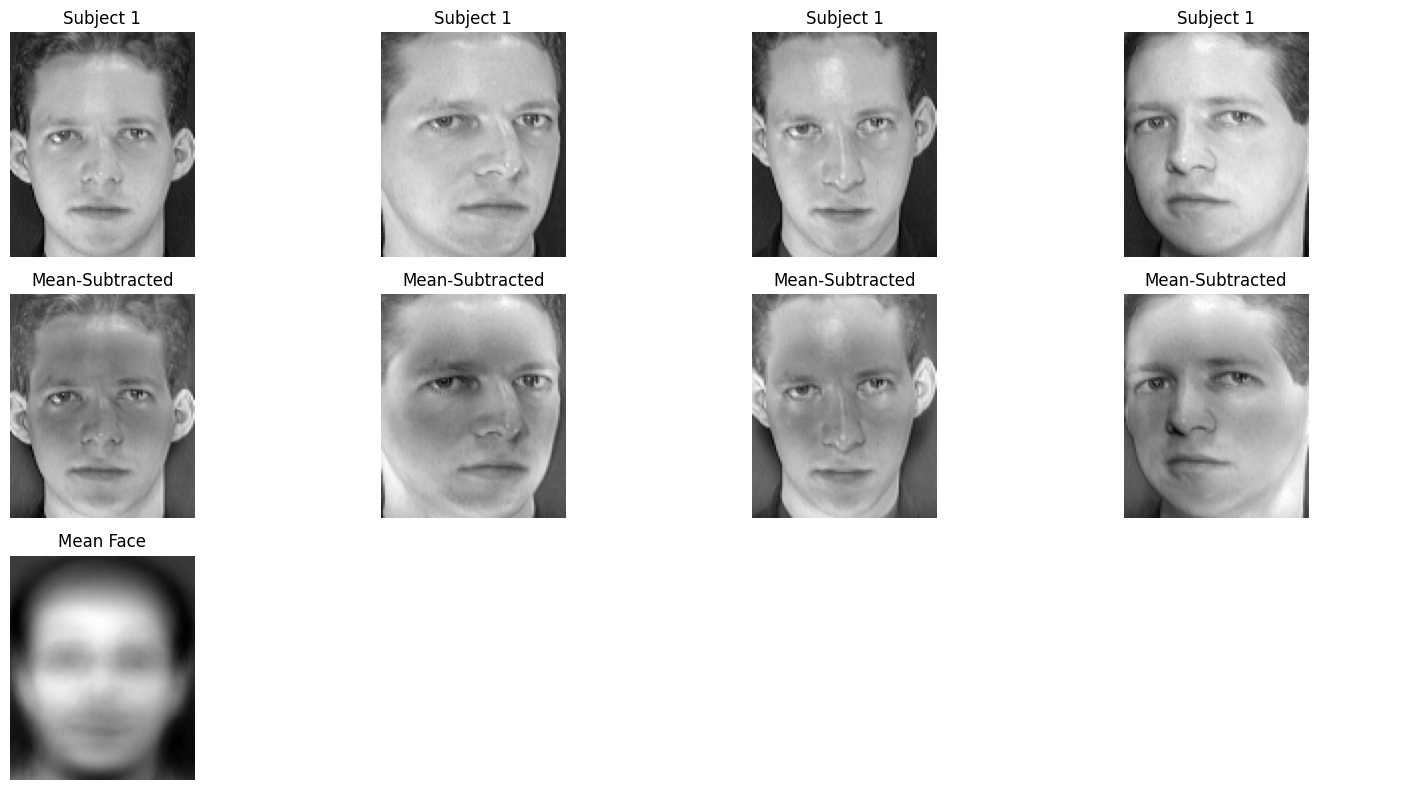


4. Normalizing images...

5. Computing PCA...
Computed 400 principal components

6. Plotting eigenvalues...


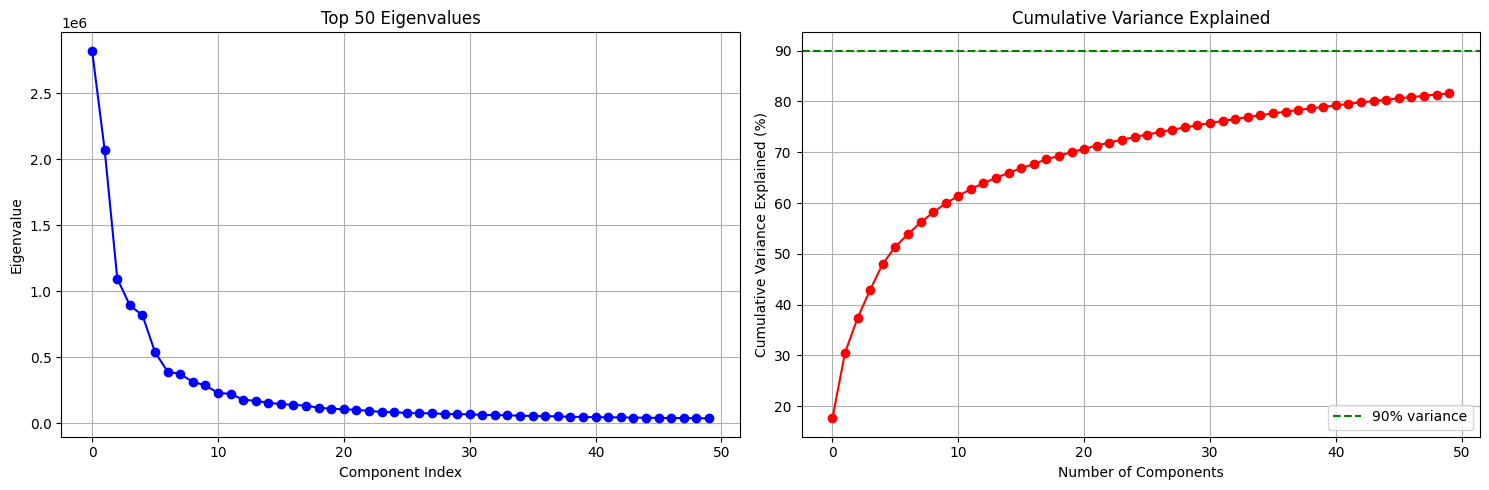


7. Visualizing top 50 eigenfaces...


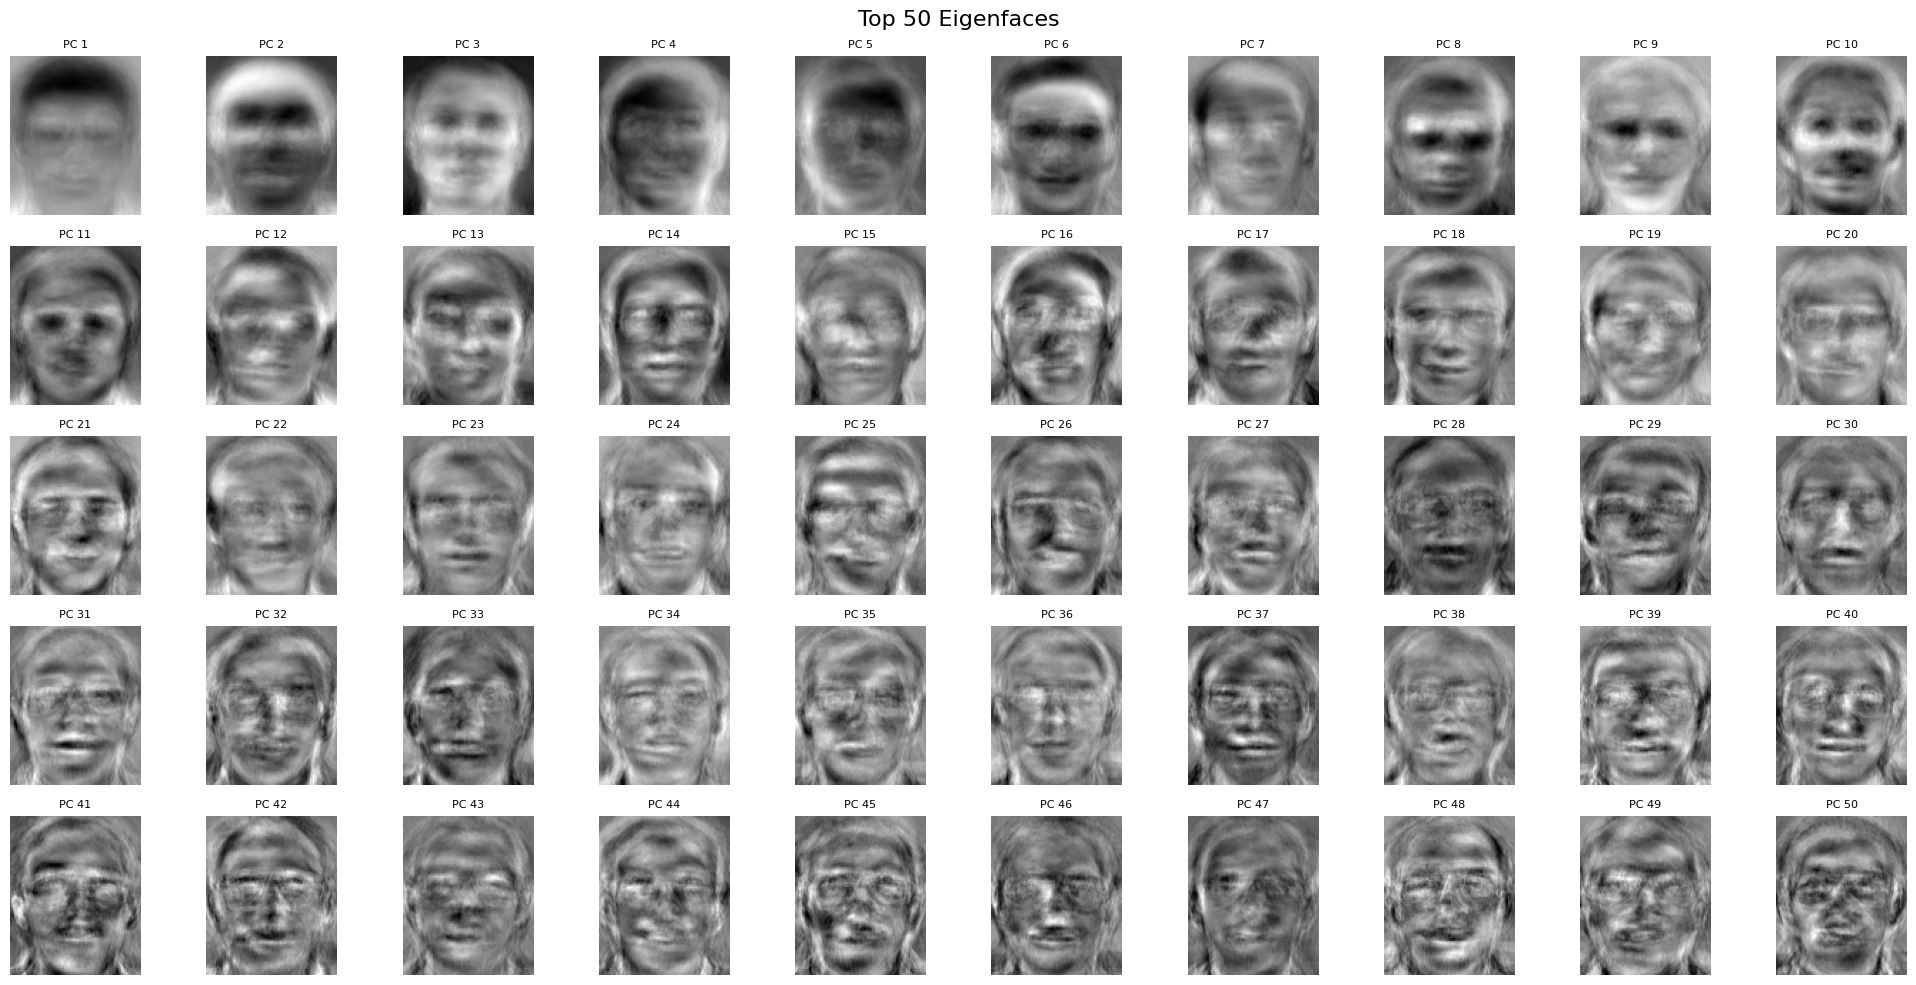


8. Finding components for 90% variance...
Number of components for 90.0% variance: 111
Actual variance retained: 90.08%

9. Reconstructing images...


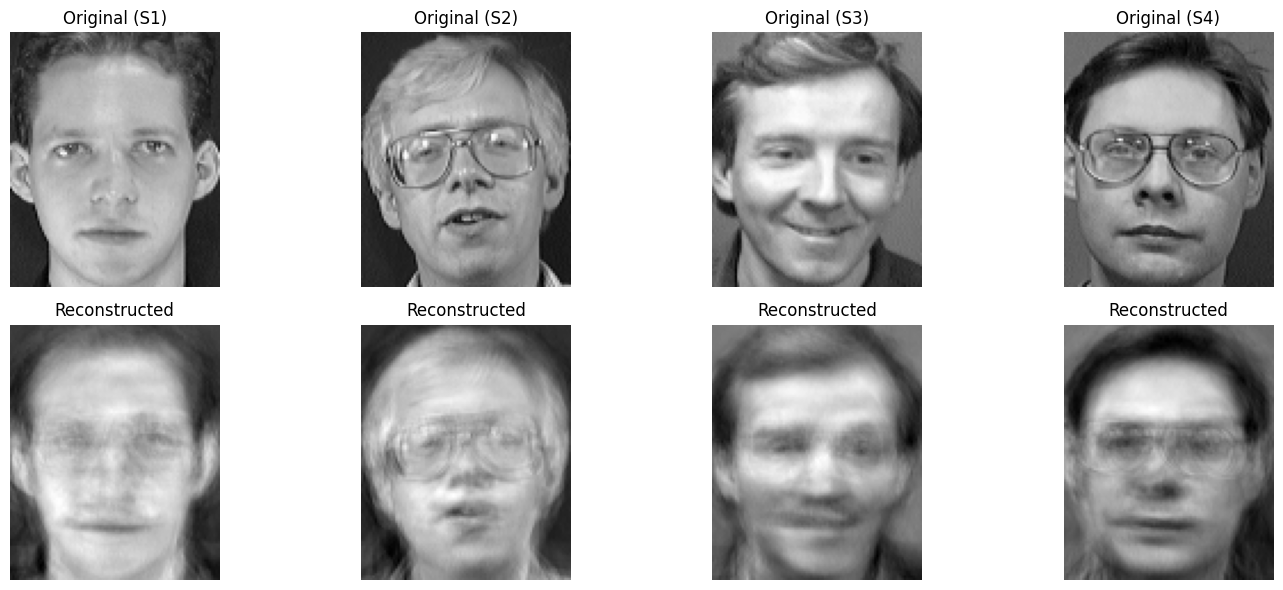


10. Splitting data (leave-one-out)...
Training samples: 360, Test samples: 40

11. Analyzing PCA component impact on classification...
Components: 5, QDA Acc: 0.850, LDA Acc: 0.700
Components: 10, QDA Acc: 0.675, LDA Acc: 0.925
Components: 15, QDA Acc: 0.900, LDA Acc: 0.950
Components: 20, QDA Acc: 0.950, LDA Acc: 0.925
Components: 25, QDA Acc: 0.950, LDA Acc: 0.925
Components: 30, QDA Acc: 0.975, LDA Acc: 0.950
Components: 35, QDA Acc: 0.975, LDA Acc: 0.950
Components: 40, QDA Acc: 0.975, LDA Acc: 0.975
Components: 45, QDA Acc: 0.975, LDA Acc: 0.975
Components: 50, QDA Acc: 0.975, LDA Acc: 0.975
Components: 55, QDA Acc: 0.975, LDA Acc: 1.000
Components: 60, QDA Acc: 0.975, LDA Acc: 0.975
Components: 65, QDA Acc: 0.975, LDA Acc: 1.000
Components: 70, QDA Acc: 0.950, LDA Acc: 1.000
Components: 75, QDA Acc: 0.950, LDA Acc: 1.000
Components: 80, QDA Acc: 0.975, LDA Acc: 1.000
Components: 85, QDA Acc: 0.950, LDA Acc: 0.975
Components: 90, QDA Acc: 0.975, LDA Acc: 0.975
Components: 95, QDA

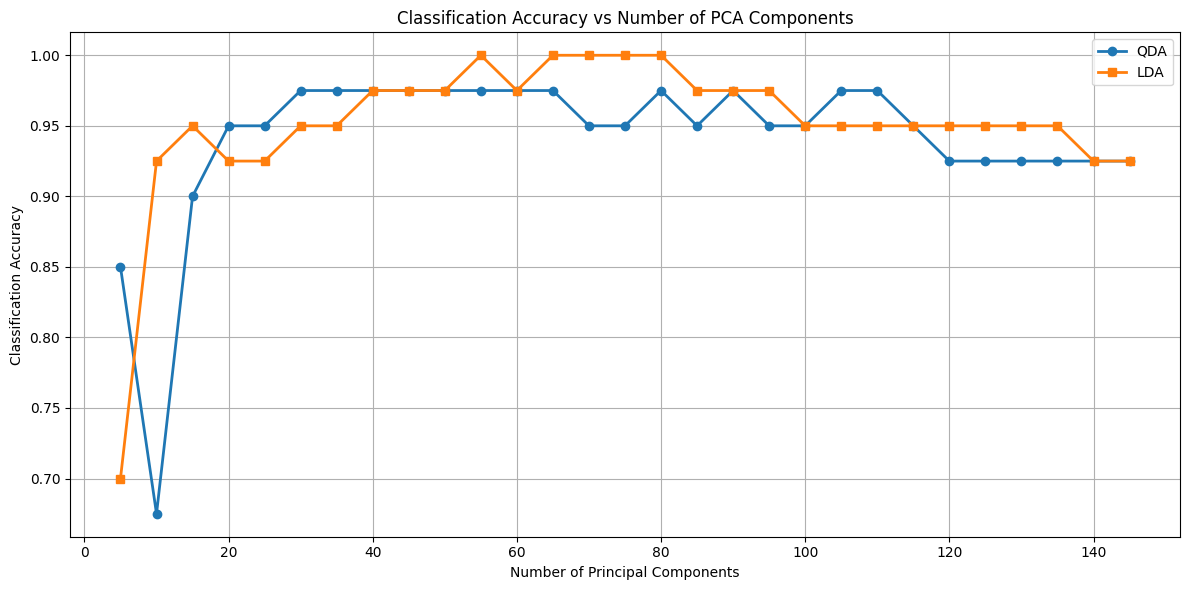


12. Evaluating best models...

QDA Results:
Accuracy: 0.9750


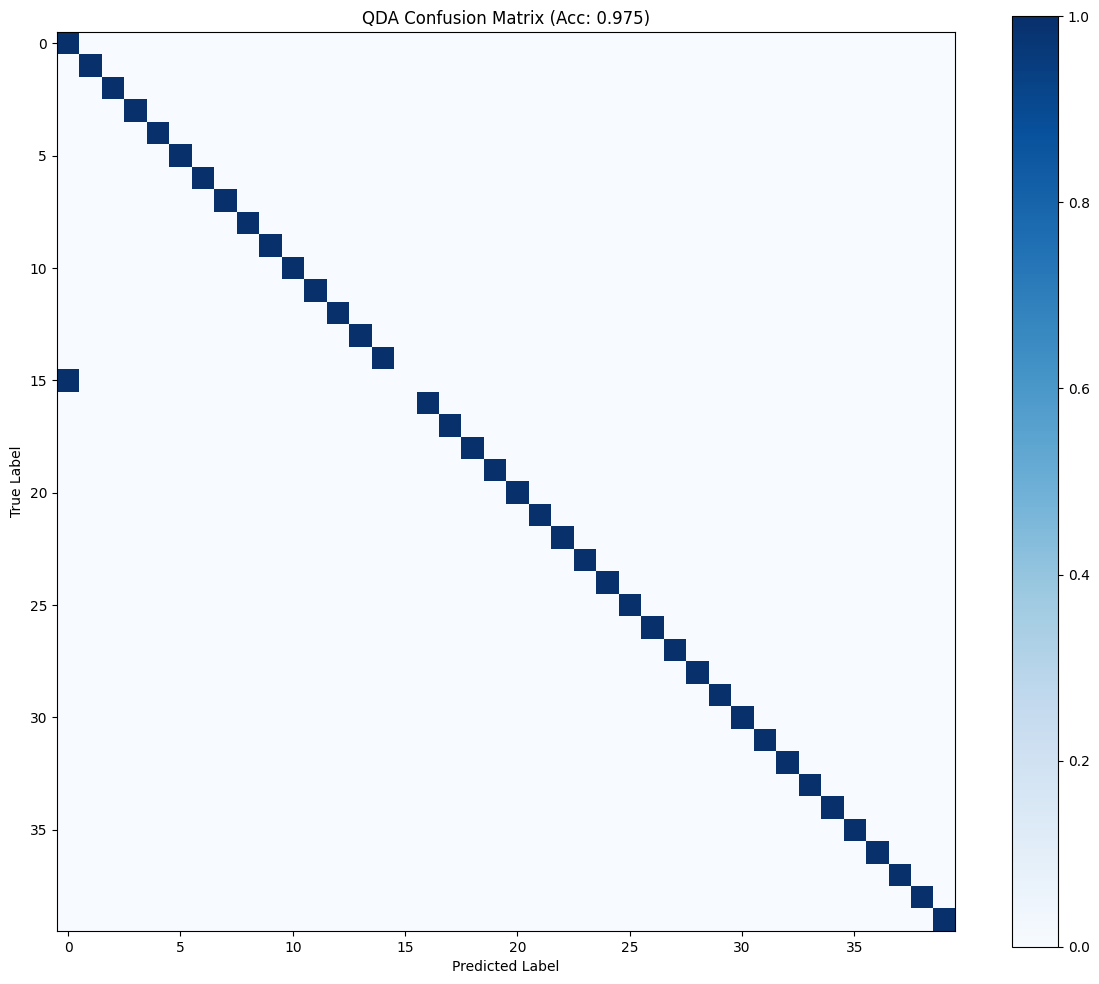


LDA Results:
Accuracy: 1.0000


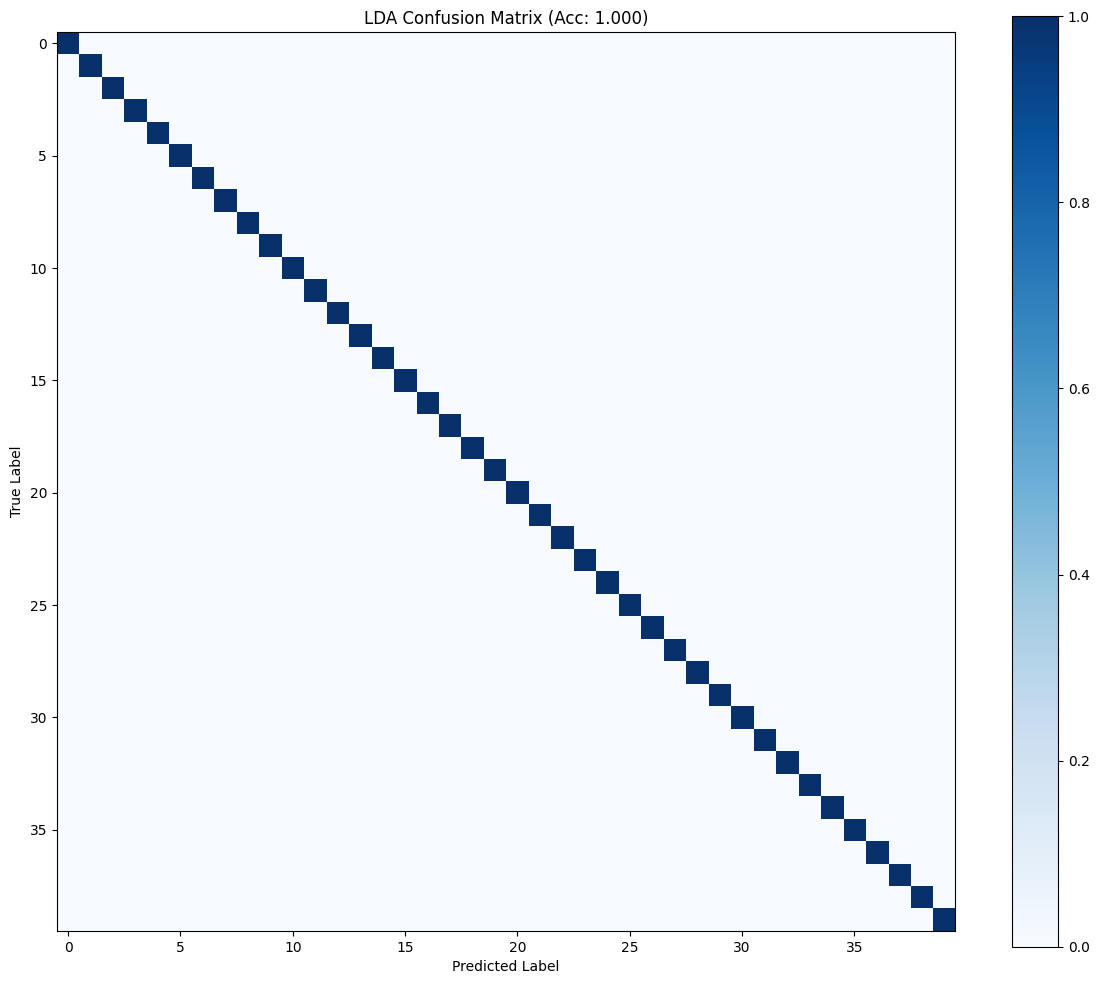

In [25]:
df, X_normalized, mean_face, eigenvalues_pca, eigenvectors_pca, train_idx, test_idx = main_pca_pipeline(data_path)

In [ ]:
eigenvectors_lda, eigenvalues_lda, X_train_lda, X_test_lda, y_pred_lda = main_fisher_lda_pipeline(
    df, X_normalized, train_idx, test_idx
)


FISHER LINEAR DISCRIMINANT ANALYSIS (LDA)

1. Analyzing data whitening...

Original data statistics:
Mean of features: 0.343064
Std of features: 38.909862
Sample correlation (mean abs off-diagonal): 0.7940

After whitening correlation (mean abs off-diagonal): 0.6600

Note: Whitening decorrelates features but is NOT essential for LDA.
LDA inherently handles correlation through the scatter matrices.
We'll proceed WITHOUT whitening for this analysis.


2. Computing scatter matrices...
SW shape: (10304, 10304)
SB shape: (10304, 10304)
SW trace: 2.33e+09
SB trace: 3.42e+09

Interpretation:
- SW (Within-class scatter): Measures variance WITHIN each class
- SB (Between-class scatter): Measures variance BETWEEN class means
- With 40 subjects and 9 training samples each:
  * SW captures intra-class variability (pose, expression, lighting)
  * SB captures inter-class variability (different individuals)

3. Solving Fisher LDA eigenvalue problem...


In [ ]:
results_comparison = compare_pca_vs_fisher_lda(
    df, X_normalized, mean_face,
    eigenvalues_pca, eigenvectors_pca,
    eigenvectors_lda, eigenvalues_lda,
    train_idx, test_idx
)

In [ ]:
X_train = X_normalized[train_idx]
y_train = df.iloc[train_idx]['subject'].values
visualize_2d_projections(X_train, y_train, eigenvectors_pca, eigenvectors_lda)

print("\n" + "="*80)
print("ASSIGNMENT COMPLETE!")
print("="*80)